In [ ]:
# Don't run this
import pandas as pd

df_Lung_Cancer = pd.read_csv('Lung Cancer.csv')
print(df_Lung_Cancer)

df_Lung_Cancer_Prediction_Dataset = pd.read_csv('Lung Cancer Prediction Dataset.csv')
print(df_Lung_Cancer_Prediction_Dataset)

df_Lung_Cancer_Risk_Dataset = pd.read_csv('Lung-Cancer-Risk-Dataset.csv')
print(df_Lung_Cancer_Risk_Dataset)

    GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0        M   69        1               2        2              1   
1        M   74        2               1        1              1   
2        F   59        1               1        1              2   
3        M   63        2               2        2              1   
4        F   63        1               2        1              1   
..     ...  ...      ...             ...      ...            ...   
304      F   56        1               1        1              2   
305      M   70        2               1        1              1   
306      M   58        2               1        1              1   
307      M   67        2               1        2              1   
308      M   62        1               1        1              2   

     CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  \
0                  1         2         1         2                  2   
1                  2         2       

First 5 rows:
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1        2        1         2                  2         2   
1                2        2        2         1                  1         1   
2                1        2        1         2                  1         2   
3                1        1        1         1                  2         1   
4                1        1        1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0                    2                    

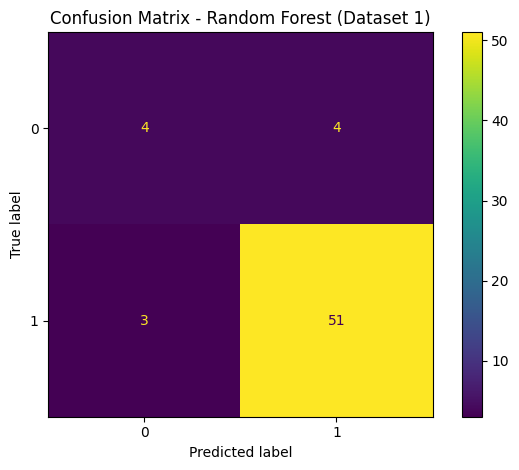


Random Forest Results: Dataset 1 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.9063
Mean Precision: 0.9358
Mean Recall   : 0.9593
Mean F1-score : 0.9469

Feature Importance Ranking
                  Feature  Importance
0                     AGE    0.146451
1                 ALLERGY    0.136953
2       ALCOHOL CONSUMING    0.096429
3   SWALLOWING DIFFICULTY    0.089078
4                 FATIGUE    0.071515
5                COUGHING    0.063552
6           PEER_PRESSURE    0.062383
7                WHEEZING    0.061783
8          YELLOW_FINGERS    0.053601
9                 ANXIETY    0.049492
10             CHEST PAIN    0.040387
11        CHRONIC DISEASE    0.039683
12    SHORTNESS OF BREATH    0.036909
13                 GENDER    0.025925
14                SMOKING    0.025860


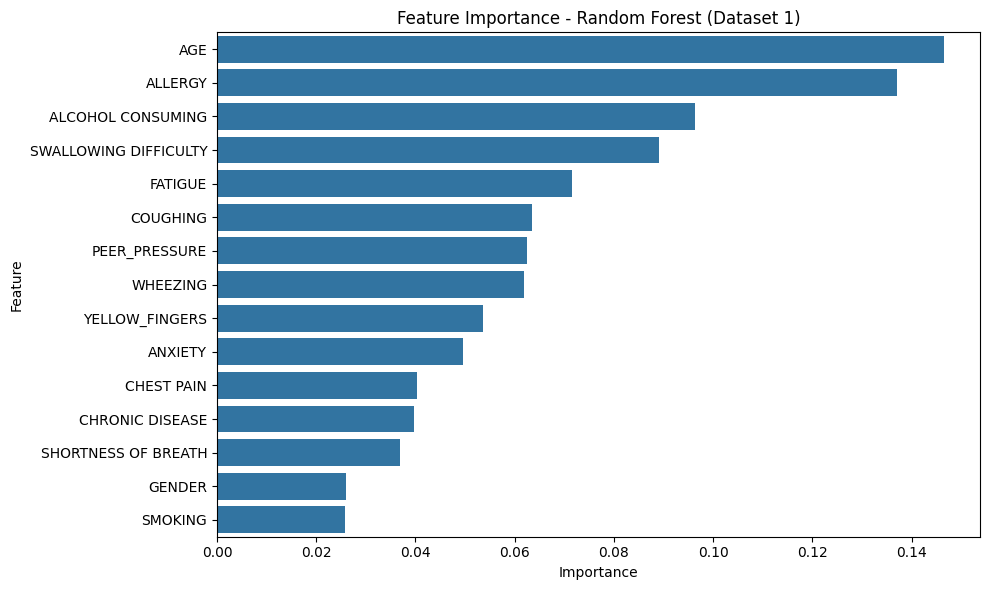


Individual Feature Results (5-Fold CV)
              Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                     AGE             1  0.682972   0.902633  0.714815   
1                 FATIGUE             1  0.676097   0.908446  0.700000   
2     SHORTNESS OF BREATH             1  0.624643   0.890742  0.651852   
3                  GENDER             1  0.602856   0.874940  0.633333   
4                COUGHING             1  0.640666   0.946563  0.625926   
5                 ALLERGY             1  0.650714   0.970422  0.618519   
6       ALCOHOL CONSUMING             1  0.637758   0.958112  0.611111   
7                WHEEZING             1  0.624326   0.949043  0.603704   
8          YELLOW_FINGERS             1  0.611740   0.926095  0.603704   
9              CHEST PAIN             1  0.605182   0.930917  0.592593   
10                SMOKING             1  0.566526   0.887825  0.574074   
11          PEER_PRESSURE             1  0.563458   0.938938  0.537037  

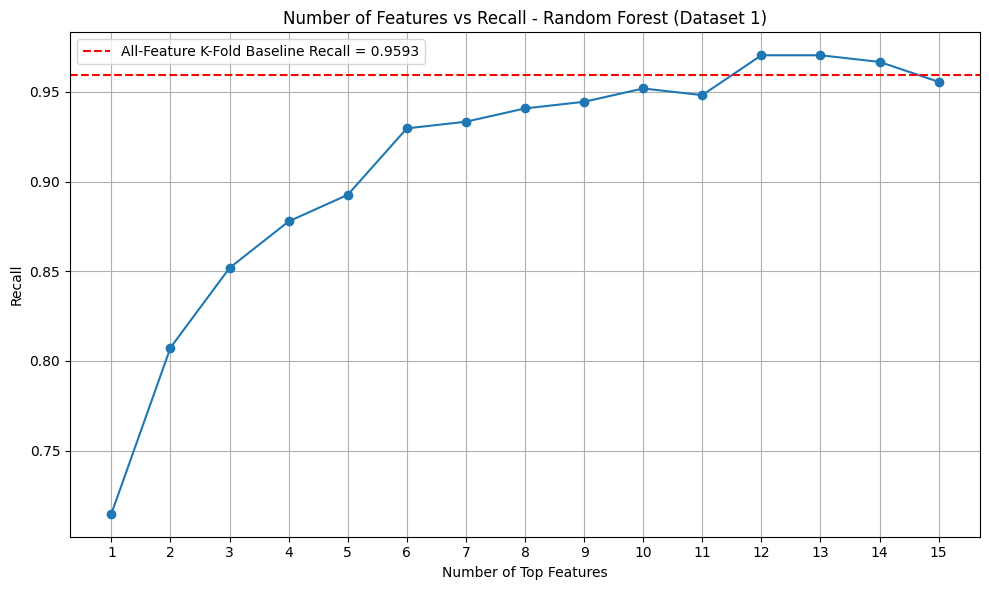

In [8]:
# DATASET 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# LOAD DATASET
df1 = pd.read_csv("Lung Cancer.csv")

# Clean column names
df1.columns = df1.columns.str.strip()

print("First 5 rows:")
print(df1.head())

print("\nColumn names:")
print(df1.columns.tolist())

print("\nDataset info:")
df1.info()

print("\nMissing values:")
print(df1.isnull().sum())

# ENCODE CATEGORICAL VARIABLES
label_encoders = {}

for col in df1.columns:
    if df1[col].dtype == "object":
        le = LabelEncoder()
        df1[col] = le.fit_transform(df1[col].astype(str))
        label_encoders[col] = le

# DEFINE TARGET AND FEATURES
target_col = "LUNG_CANCER"
X1 = df1.drop(columns=[target_col])
y1 = df1[target_col]

print("\nClass distribution:")
print(y1.value_counts())

print("\nClass distribution (proportion):")
print(y1.value_counts(normalize=True))

# ORIGINAL TRAIN-TEST BASELINE
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

rf_model_split = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_split.fit(X1_train, y1_train)
y1_pred = rf_model_split.predict(X1_test)

accuracy_1 = accuracy_score(y1_test, y1_pred)
precision_1 = precision_score(y1_test, y1_pred, zero_division=0)
recall_1 = recall_score(y1_test, y1_pred, zero_division=0)
f1_1 = f1_score(y1_test, y1_pred, zero_division=0)

print("\nRandom Forest Results: Dataset 1 (80/20 Split Baseline)")
print(f"Accuracy : {accuracy_1:.4f}")
print(f"Precision: {precision_1:.4f}")
print(f"Recall   : {recall_1:.4f}")
print(f"F1-score : {f1_1:.4f}")

cm1 = confusion_matrix(y1_test, y1_pred)

print("\nConfusion Matrix:")
print(cm1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Dataset 1)")
plt.tight_layout()
plt.show()

# K-FOLD BASELINE
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X1,
    y1,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nRandom Forest Results: Dataset 1 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE
rf_model_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_full.fit(X1, y1)

feature_importance_df = pd.DataFrame({
    "Feature": X1.columns,
    "Importance": rf_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest (Dataset 1)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X1[[feature]]

    single_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X1[selected_features]

    topk_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X1.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Random Forest (Dataset 1)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

First 5 rows:
   AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0   68       1        1                     1              1   
1   81       1        1                     0              0   
2   58       1        1                     0              0   
3   44       0        1                     0              1   
4   72       0        1                     1              1   

   EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                      1                  0     57.831178                0   
1                      1                  1     47.694835                1   
2                      0                  0     59.577435                0   
3                      1                  0     59.785767                0   
4                      1                  1     59.733941                0   

   BREATHING_ISSUE  ALCOHOL_CONSUMPTION  THROAT_DISCOMFORT  OXYGEN_SATURATION  \
0                0                    1            

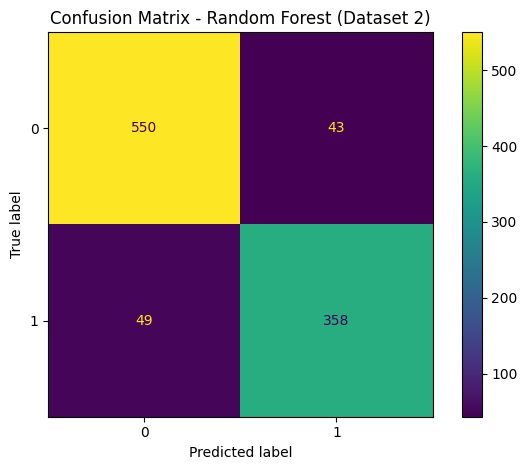


Random Forest Results: Dataset 2 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.9098
Mean Precision: 0.8995
Mean Recall   : 0.8768
Mean F1-score : 0.8879

Feature Importance Ranking
                   Feature  Importance
0                  SMOKING    0.219115
1             ENERGY_LEVEL    0.151450
2        THROAT_DISCOMFORT    0.112749
3          BREATHING_ISSUE    0.103667
4        OXYGEN_SATURATION    0.094590
5                      AGE    0.079579
6   SMOKING_FAMILY_HISTORY    0.044630
7            STRESS_IMMUNE    0.035720
8    EXPOSURE_TO_POLLUTION    0.032803
9           FAMILY_HISTORY    0.019014
10         IMMUNE_WEAKNESS    0.018765
11           MENTAL_STRESS    0.016215
12                  GENDER    0.015286
13       LONG_TERM_ILLNESS    0.014853
14    FINGER_DISCOLORATION    0.013962
15         CHEST_TIGHTNESS    0.013850
16     ALCOHOL_CONSUMPTION    0.013754


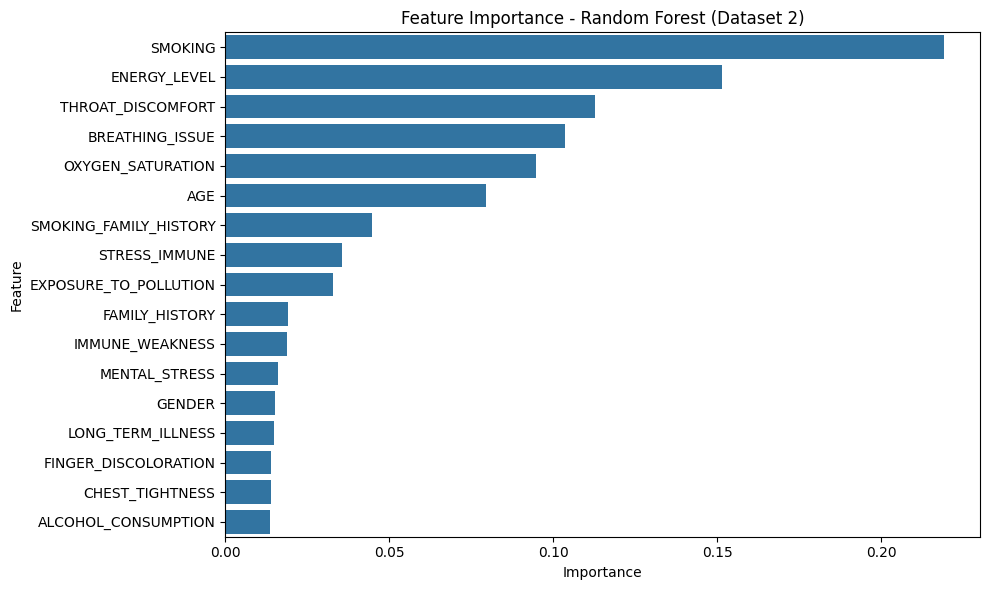


Individual Feature Results (5-Fold CV)
               Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0          BREATHING_ISSUE             1    0.5506   0.473846  0.930779   
1                  SMOKING             1    0.6830   0.567832  0.928816   
2        THROAT_DISCOMFORT             1    0.5912   0.499271  0.855173   
3     FINGER_DISCOLORATION             1    0.4938   0.417845  0.616573   
4          CHEST_TIGHTNESS             1    0.4940   0.417942  0.616111   
5            MENTAL_STRESS             1    0.5364   0.447877  0.593549   
6    EXPOSURE_TO_POLLUTION             1    0.5438   0.452914  0.573396   
7                   GENDER             1    0.4910   0.397320  0.484042   
8          IMMUNE_WEAKNESS             1    0.5794   0.483254  0.468350   
9        LONG_TERM_ILLNESS             1    0.5174   0.414487  0.446746   
10                     AGE             1    0.5022   0.399891  0.443772   
11            ENERGY_LEVEL             1    0.5344   0.42871

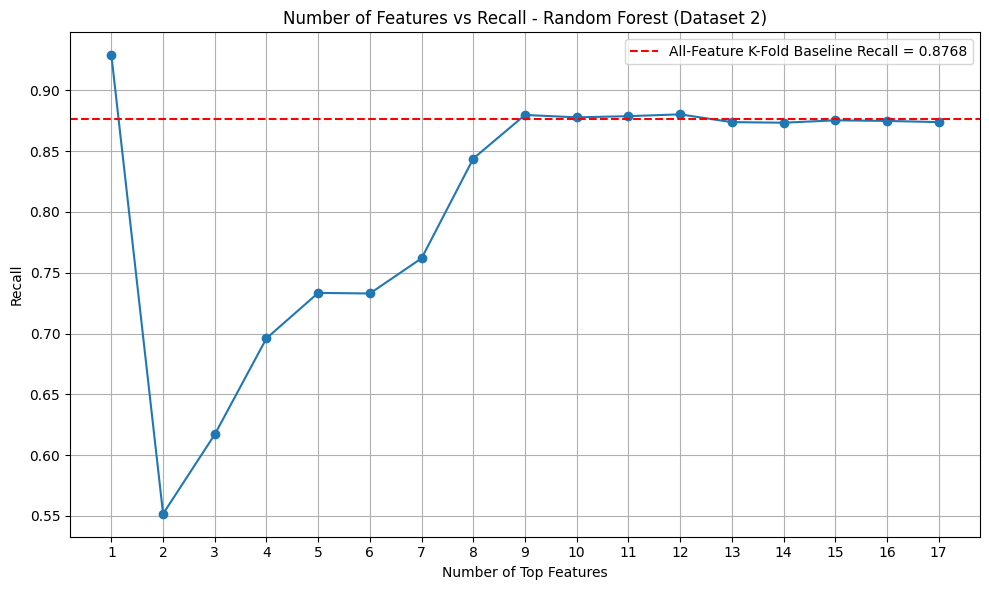

In [9]:
# DATASET 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# LOAD DATASET
df2 = pd.read_csv("Lung Cancer Prediction Dataset.csv")

# Clean column names
df2.columns = df2.columns.str.strip()

print("First 5 rows:")
print(df2.head())

print("\nColumn names:")
print(df2.columns.tolist())

print("\nDataset info:")
df2.info()

print("\nMissing values:")
print(df2.isnull().sum())

# ENCODE CATEGORICAL VARIABLES
label_encoders = {}

for col in df2.columns:
    if df2[col].dtype == "object":
        le = LabelEncoder()
        df2[col] = le.fit_transform(df2[col].astype(str))
        label_encoders[col] = le

# DEFINE TARGET AND FEATURES
target_col = "PULMONARY_DISEASE"
X2 = df2.drop(columns=[target_col])
y2 = df2[target_col]

print("\nClass distribution:")
print(y2.value_counts())

print("\nClass distribution (proportion):")
print(y2.value_counts(normalize=True))

# ORIGINAL TRAIN-TEST BASELINE
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

rf_model_split = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_split.fit(X2_train, y2_train)
y2_pred = rf_model_split.predict(X2_test)

accuracy_2 = accuracy_score(y2_test, y2_pred)
precision_2 = precision_score(y2_test, y2_pred, zero_division=0)
recall_2 = recall_score(y2_test, y2_pred, zero_division=0)
f1_2 = f1_score(y2_test, y2_pred, zero_division=0)

print("\nRandom Forest Results: Dataset 2 (80/20 Split Baseline)")
print(f"Accuracy : {accuracy_2:.4f}")
print(f"Precision: {precision_2:.4f}")
print(f"Recall   : {recall_2:.4f}")
print(f"F1-score : {f1_2:.4f}")

cm2 = confusion_matrix(y2_test, y2_pred)

print("\nConfusion Matrix:")
print(cm2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Dataset 2)")
plt.tight_layout()
plt.show()

# K-FOLD BASELINE
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X2,
    y2,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nRandom Forest Results: Dataset 2 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE
rf_model_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_full.fit(X2, y2)

feature_importance_df = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": rf_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest (Dataset 2)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X2[[feature]]

    single_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y2,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X2[selected_features]

    topk_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y2,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X2.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Random Forest (Dataset 2)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

First 5 rows:
   patient_id  age  gender  pack_years radon_exposure asbestos_exposure  \
0      100000   69    Male   66.025244           High                No   
1      100001   32  Female   12.780800           High                No   
2      100002   89  Female    0.408278         Medium               Yes   
3      100003   78  Female   44.065232            Low                No   
4      100004   38  Female   44.432440         Medium               Yes   

  secondhand_smoke_exposure copd_diagnosis alcohol_consumption family_history  \
0                        No            Yes            Moderate             No   
1                       Yes            Yes            Moderate            Yes   
2                       Yes            Yes                 NaN             No   
3                       Yes             No            Moderate             No   
4                        No            Yes                 NaN            Yes   

  lung_cancer  
0          No  
1         Yes  


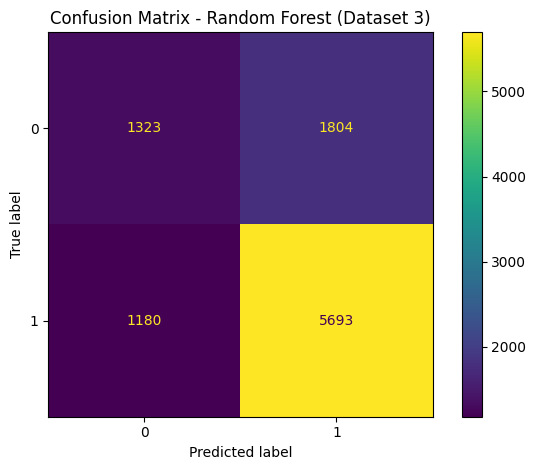


Random Forest Results: Dataset 3 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.6997
Mean Precision: 0.7584
Mean Recall   : 0.8265
Mean F1-score : 0.7909

Feature Importance Ranking
                     Feature  Importance
0                 pack_years    0.508878
1                        age    0.308004
2             radon_exposure    0.041983
3          asbestos_exposure    0.032042
4             copd_diagnosis    0.031493
5             family_history    0.020472
6                     gender    0.019689
7  secondhand_smoke_exposure    0.019125
8        alcohol_consumption    0.018313


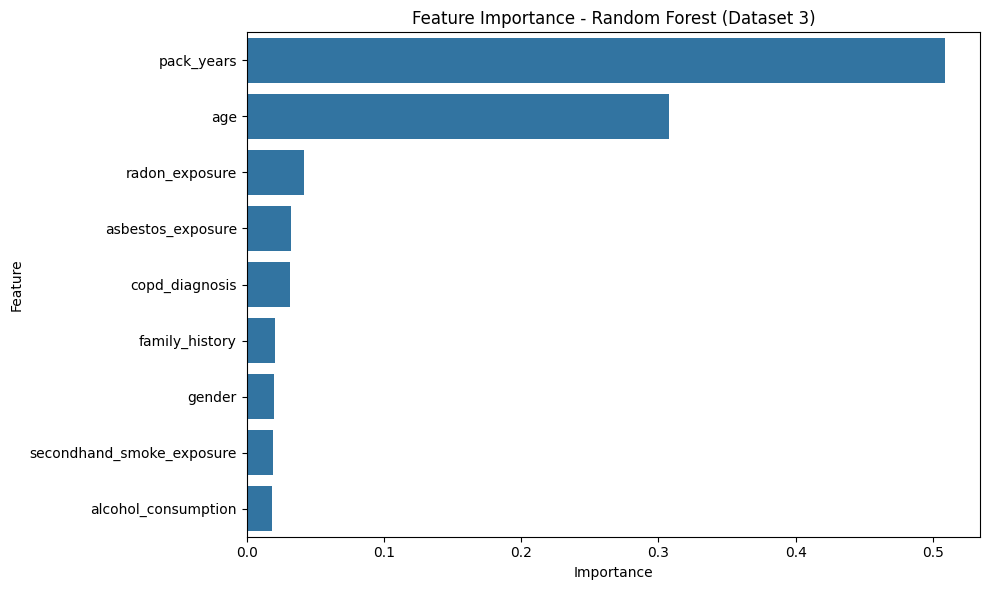


Individual Feature Results (5-Fold CV)
                 Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                 pack_years             1   0.61264   0.718176  0.718223   
1        alcohol_consumption             1   0.56840   0.691233  0.672331   
2                        age             1   0.60398   0.743148  0.647625   
3                     gender             1   0.53286   0.682118  0.597803   
4             copd_diagnosis             1   0.57168   0.758276  0.553108   
5          asbestos_exposure             1   0.57182   0.760670  0.550052   
6             family_history             1   0.54942   0.736869  0.535706   
7  secondhand_smoke_exposure             1   0.54542   0.732083  0.534018   
8             radon_exposure             1   0.49698   0.776887  0.376149   

   F1-score  
0  0.718195  
1  0.681633  
2  0.692101  
3  0.622719  
4  0.639627  
5  0.638434  
6  0.620373  
7  0.617544  
8  0.506861  

Top-k Feature Combination Results (5-Fold CV)
  

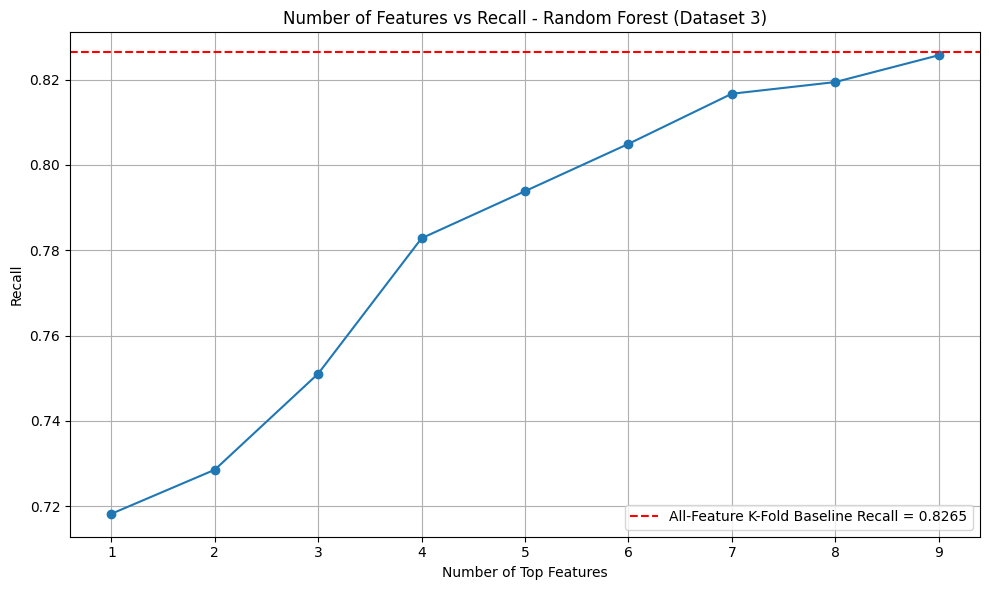

In [11]:
# DATASET 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# LOAD DATASET
df3 = pd.read_csv("Lung-Cancer-Risk-Dataset.csv")

# Clean column names
df3.columns = df3.columns.str.strip()

print("First 5 rows:")
print(df3.head())

print("\nColumn names:")
print(df3.columns.tolist())

print("\nDataset info:")
df3.info()

print("\nMissing values:")
print(df3.isnull().sum())

# DROP ID COLUMN IF IT EXISTS
if "patient_id" in df3.columns:
    df3 = df3.drop(columns=["patient_id"])

# FILL MISSING VALUES
for col in df3.columns:
    if df3[col].dtype == "object":
        df3[col] = df3[col].fillna(df3[col].mode()[0])
    else:
        df3[col] = df3[col].fillna(df3[col].median())

print("\nMissing values after filling:")
print(df3.isnull().sum())

# ENCODE CATEGORICAL VARIABLES
label_encoders = {}

for col in df3.columns:
    if df3[col].dtype == "object":
        le = LabelEncoder()
        df3[col] = le.fit_transform(df3[col].astype(str))
        label_encoders[col] = le

# DEFINE TARGET AND FEATURES
target_col = "lung_cancer"
X3 = df3.drop(columns=[target_col])
y3 = df3[target_col]

print("\nClass distribution:")
print(y3.value_counts())

print("\nClass distribution (proportion):")
print(y3.value_counts(normalize=True))

# ORIGINAL TRAIN-TEST BASELINE
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

rf_model_split = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_split.fit(X3_train, y3_train)
y3_pred = rf_model_split.predict(X3_test)

accuracy_3 = accuracy_score(y3_test, y3_pred)
precision_3 = precision_score(y3_test, y3_pred, zero_division=0)
recall_3 = recall_score(y3_test, y3_pred, zero_division=0)
f1_3 = f1_score(y3_test, y3_pred, zero_division=0)

print("\nRandom Forest Results: Dataset 3 (80/20 Split Baseline)")
print(f"Accuracy : {accuracy_3:.4f}")
print(f"Precision: {precision_3:.4f}")
print(f"Recall   : {recall_3:.4f}")
print(f"F1-score : {f1_3:.4f}")

cm3 = confusion_matrix(y3_test, y3_pred)

print("\nConfusion Matrix:")
print(cm3)

disp = ConfusionMatrixDisplay(confusion_matrix=cm3)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Dataset 3)")
plt.tight_layout()
plt.show()

# K-FOLD BASELINE
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X3,
    y3,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nRandom Forest Results: Dataset 3 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE
rf_model_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_full.fit(X3, y3)

feature_importance_df = pd.DataFrame({
    "Feature": X3.columns,
    "Importance": rf_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest (Dataset 3)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X3[[feature]]

    single_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X3[selected_features]

    topk_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X3.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Random Forest (Dataset 3)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()